In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


# Load your data into a pandas DataFrame (assuming your data is in a CSV file)
df = pd.read_csv('/content/drive/MyDrive/DS Projects/2024 Fall/Mental Health Osama/Mental Health Dataset.csv')
df.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
df.shape

(287162, 14)

# Data Cleaning and Preprocessing

In [ ]:
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [ ]:
df.describe()

,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000,287162.000000
mean,3.020239,0.203147,0.790453,1.008100,2.963205,1.023579,1.074763,0.962182,0.971326,0.944087,0.929810,0.980321,0.228798,0.923374
std,1.352520,0.604174,0.977800,0.999969,1.420193,0.810797,0.817867,0.820001,0.808381,0.998437,0.805583,0.803710,0.480709,0.853761
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,4.000000,0.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,2.000000
max,5.000000,2.000000,2.000000,2.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42564 sha256=9a810db5ef548ac2438bb3f69a7272dcf250a46e358e743cd297cbd9b6aa11e1
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer


In [ ]:
df = df.dropna()
columns_to_drop = ['Timestamp', 'Gender', 'Country']

# Drop the specified columns
df = df.drop(columns=columns_to_drop)

In [ ]:
# Define the mapping dictionary
mapping_dict = {'Yes': 2, 'Maybe': 1, 'No': 0, 'Not sure': 1, 'High': 2, 'Medium': 1, 'Low': 0 ,'Business': 1, 'Corporate': 2, 'Housewife': 3, 'Student': 4, 'Others': 5, '1-14 days': 1, '15-30 days': 2, '31-60 days': 3, 'Go out Every day': 4, 'More than 2 months': 5}

# Apply the mapping to each column
for col in df.columns:
    df[col] = df[col].map(mapping_dict)

In [ ]:
df.head()

,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,2,0,2,2,1,2,0,2,1,0,0,2,1,2
4,2,0,2,2,1,2,0,2,1,0,0,2,0,2
5,2,0,0,2,1,2,0,2,1,0,0,2,1,1
6,2,0,2,2,1,2,0,2,1,0,0,2,0,1
7,2,0,0,0,1,2,0,2,1,0,0,2,0,0


In [ ]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df)
chi_square_value, p_value

(78420.01658562612, 0.0)

In [ ]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

fa = FactorAnalyzer()
fa.set_params(n_factors=14, rotation=None)
fa.fit(df)
ev, v = fa.get_eigenvalues()
ev

array([1.5201633 , 1.16120048, 1.099337  , 1.0886076 , 1.0802463 ,
       1.02767338, 0.99286993, 0.96272154, 0.94024237, 0.93759177,
       0.8950333 , 0.85156804, 0.84433003, 0.59841497])

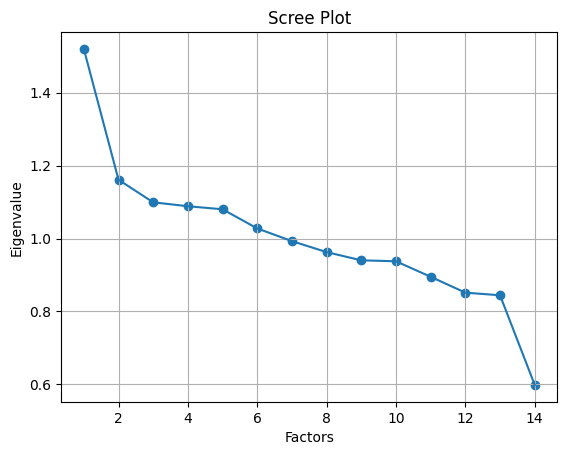

In [ ]:
# Create scree plot using matplotlib
plt.scatter(range(1,df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [ ]:
fa = FactorAnalyzer()
fa.set_params(n_factors=5, rotation="varimax")
fa.fit(df)

FactorAnalyzer(n_factors=5, rotation='varimax', rotation_kwargs={})

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
loadings = fa.loadings_
loadings_df = pd.DataFrame(loadings, index=df.columns)

print(loadings_df)

                                0         1         2         3         4
Occupation               0.008288 -0.016512  0.074342 -0.007852 -0.142065
self_employed            0.046488 -0.006811 -0.003306  0.170378 -0.004597
family_history           0.438703  0.024808  0.008200 -0.067849  0.011260
treatment                0.843569  0.039636  0.003770 -0.002935  0.007044
Days_Indoors            -0.043278  0.979846  0.115687  0.047718  0.132646
Growing_Stress           0.007824 -0.048479  0.068735 -0.005237  0.378383
Changes_Habits          -0.002708 -0.004873 -0.001718  0.002783 -0.042741
Mental_Health_History    0.000462 -0.013624  0.201011  0.000080  0.050935
Mood_Swings              0.002120  0.045564  0.148107 -0.001052 -0.044409
Coping_Struggles         0.011899  0.068966 -0.010735 -0.011092 -0.004939
Work_Interest            0.005924 -0.065386  0.178405 -0.006900  0.068100
Social_Weakness          0.000631 -0.013107 -0.374529 -0.000837  0.154389
mental_health_interview -0.065694 -0.0

In [ ]:
# Get variance of each factors
fa.get_factor_variance()

(array([1.00238624, 0.97703981, 0.25833016, 0.22245893, 0.21612903]),
 array([0.07159902, 0.06978856, 0.01845215, 0.01588992, 0.01543779]),
 array([0.07159902, 0.14138757, 0.15983973, 0.17572965, 0.19116744]))

In [ ]:
import pandas as pd
import numpy as np

# Sample data from fa.get_factor_variance()
factor_variance = (np.array([1.00238624, 0.97703981, 0.25833016, 0.22245893, 0.21612903]),
                   np.array([0.07159902, 0.06978856, 0.01845215, 0.01588992, 0.01543779]),
                   np.array([0.07159902, 0.14138757, 0.15983973, 0.17572965, 0.19116744]))

# Extracting the values from the tuple
ss_loadings = factor_variance[0]
prop_var = factor_variance[1]
cum_var = factor_variance[2]

# Create a DataFrame with the transposed data
data_transposed = {'SS Loadings': ss_loadings, 'Proportion Var': prop_var, 'Cumulative Var': cum_var}
df_transposed = pd.DataFrame(data_transposed, index=['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5'])

# Print the transposed DataFrame
print(df_transposed.to_string())


         SS Loadings  Proportion Var  Cumulative Var
Factor1     1.002386        0.071599        0.071599
Factor2     0.977040        0.069789        0.141388
Factor3     0.258330        0.018452        0.159840
Factor4     0.222459        0.015890        0.175730
Factor5     0.216129        0.015438        0.191167
